#### CONCATENATION

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

In [ ]:
df1 = df[["Name", "Sex", "Age"]][0:5]
# First selects only "Name", "Sex", "Age" columns → then takes first 5 rows → stores result in df1

In [ ]:
df1

In [ ]:
df2 = df[["Name", "Sex", "Age"]][5:10]

In [ ]:
df2

In [ ]:
"PW" + "Skill"

In [ ]:
df1

In [ ]:
df2

In [ ]:
pd.concat([df1, df2], axis =0) #Concatenate pandas objects along a particular axis.
# Joins df1 and df2 vertically (row-wise) → df2 rows are added below df1

In [ ]:
pd.concat([df1, df2], axis =1)
# Joins df1 and df2 horizontally (column-wise) → df2 columns are added beside df1

In [ ]:
# Resets the index of df2 (0,1,2,...) → removes old index (drop=True) → updates df2 itself (inplace=True)
df2.reset_index(drop = True, inplace = True)
df2

In [ ]:
df1

In [ ]:
pd.concat([df1, df2], axis =1)
# Combines df1 and df2 side by side (column-wise) → rows are matched by index

#### MERGE

In [ ]:
df1 = pd.DataFrame({'key1':[1,2,4,5,6],
                      'key2':[4,5,6,7,8],
                      'key3':[3,4,5,6,6]
})

# Creates a DataFrame named df1 with 3 columns (key1, key2, key3) and given list values as rows

In [ ]:
df1

In [ ]:
df2 =  pd.DataFrame({'key1':[1,2,45,6,67],
                      'key4':[56,5,6,7,8],
                      'key5':[3,56,5,6,6]
}
)

# Creates a DataFrame named df2 with columns key1, key4, key5 and their respective values

In [ ]:
df2

In [ ]:
df1

In [ ]:
df2

In [ ]:
pd.merge(df1, df2, how = 'inner')
# Combines df1 and df2 based on common column(s) (here "key1") → keeps only matching rows in both dataframes

**pehle matching keys (key1) se common values li jaati hain (1, 2, 6) fir df1 aur df2 me jaha ye values milti hain (value match) waha se poori row uthayi jaati hai, dono rows ko combine kar diya jata hai, index ka koi role nahi hota**|

**Important line (yaad rakhna):**

- 👉 Row match key1 se hota hai
- 👉 Baaki values same row se uthai jaati hain (random nahi hoti)

In [ ]:
pd.merge(df1, df2, how = 'left')

- df1 pura aata hai (same order me)
- df2 me jaha key1 = 1, 2, 6 milta hai, usi rows se key4, key5 uthaye jaate hain
- aur unhe df1 ki un rows me fill kiya jata hai jaha key1 = 1, 2, 6 hai
- baaki jaha match nahi hota → NaN

after writing the base table
- value uthegi df2 ke key4, key5 ke un rows se jaha key1 = 1, 2, 6 hai
- aur fill hogi df1 ki un rows me jaha key1 = 1, 2, 6 hai
- baaki jaha match nahi hota → NaN

In [ ]:
df2

In [ ]:
pd.merge(df1, df2, how = 'right')

# df2 pura aata hai (same order me)
# df1 me jaha key1 = 1, 2, 6 milta hai, usi rows se key2, key3 uthaye jaate hain
# aur unhe df2 ki un rows me fill kiya jata hai jaha key1 = 1, 2, 6 hai
# baaki jaha match nahi hota → df1 ke columns me NaN

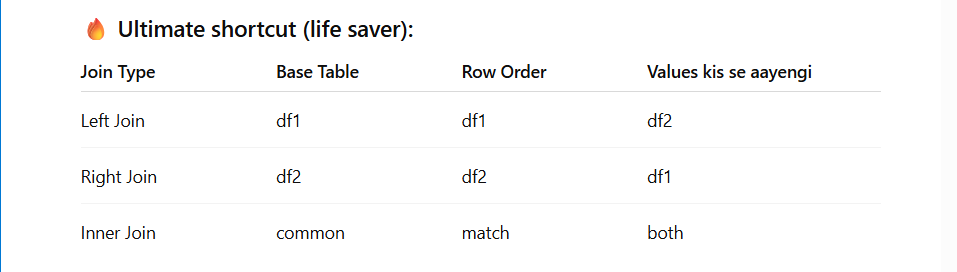

In [ ]:
pd.merge(df1, df2, how = 'outer') #all the keys from both the datframe
# df1 aur df2 dono ki saari unique key1 values li jaati hain (common + non-common sab)
# fir key1 ke basis pe match kiya jata hai
# jaha match hota hai → dono tables ki values combine ho jaati hain
# jaha match nahi hota → jis table me value missing hoti hai uske columns me NaN aa jata hai

**df1 aur df2 dono ki saari unique key1 values li jaati hain (common + non-common sab), fir key1 ke basis pe match kiya jata hai value wise jis number ke saamne jo values hai dono tables ke unko rkha jaata hai and jaha value match na ho waha NaN** **and values match jo common column hai uske basis pr hota hai (in this case key1)**

In [ ]:
df1

In [ ]:
df2

In [ ]:
pd.merge(df1, df2, how = 'cross')
# Creates a Cartesian product of df1 and df2 (each row of df1 × each row of df2)
# No matching column is used (key1 is ignored)
# Every row of df1 is combined with every row of df2
# Total rows = (number of rows in df1) × (number of rows in df2)

**df1 aur df2 ka Cartesian product banta hai (har row df1 ki × har row df2 ki), koi matching column use nahi hota (key1 ignore ho jata hai), har df1 row, df2 ki har row ke saath combine hoti hai, total rows = (df1 rows) × (df2 rows)**

In [ ]:
pd.merge(df1, df2, how = "left", left_on = "key2", right_on = "key4")
#df1 is the base table → all rows of df1 will appear (in the same order)
#in this condition, df1’s key2 is matched with df2’s key4
#wherever common values are found in both columns (key2 & key4), the corresponding row values from df2 (key1, key4, key5) are taken and these values are placed in the rows of df1 where key2 matches
#wherever no match is found → df2’s columns will contain NaN

- df1 base table hai → df1 ki saari rows aayengi (same order me)
- is condition me df1 ke key2 ko df2 ke key4 ke saath merge kiya gaya hai
- jaha dono columns (key2 & key4) me common values milti hain, waha df2 ki corresponding row se (key1, key4, key5) ki values uthakar
- df1 ki unhi rows me place ki jaati hain jaha key2 match karta hai
- aur jaha match nahi hota → df2 ke columns me NaN aa jata hai

In [ ]:
#join
df1 = pd.DataFrame({'key1':[1,2,4,5,6],
                      'key2':[4,5,6,7,8],
                      'key3':[3,4,5,6,6]},
                    index = ['a', 'b', 'c', 'd', 'e']
)

# Creates a DataFrame named df1 with columns key1, key2, key3
# and assigns custom row labels (index) as 'a', 'b', 'c', 'd', 'e'

In [ ]:
df2 =  pd.DataFrame({'key6':[1,2,45,6,67],
                      'key4':[56,5,6,7,8],
                      'key5':[3,56,5,6,6]
},
index = ['a', 'b', 'h', 'i', 'j']
)

# Creates a DataFrame named df2 with columns key6, key4, key5
# and assigns custom row labels (index) as 'a', 'b', 'h', 'i', 'j'

In [ ]:
df1

In [ ]:
df2

In [ ]:
df1.join(df2, how = "inner") #Join columns of another DataFrame.
# Joins df1 and df2 based on index (row labels), not on column values
# Keeps only the common indexes present in both dataframes (inner join)
# Here, common indexes are 'a' and 'b'
# Combines columns of df1 and df2 for these matching indexes

In [ ]:
df1.join(df2, how = "left")
# Joins df1 and df2 based on index (row labels), not on column values
# Keeps only the common indexes present in both dataframes (inner join)
# Here, common indexes are 'a' and 'b'
# Combines columns of df1 and df2 for these matching indexes

In [ ]:
df1.join(df2, how = "right")
# Joins df1 and df2 based on index (row labels), not on column values
# df2 is the base table → all indexes of df2 will appear (same order)
# df1 will provide values only where indexes match with df2
# jaha index match hota hai → df1 ke columns (key1, key2, key3) fill hote hain
# jaha match nahi hota → df1 ke columns me NaN aa jata hai

In [ ]:
df1.join(df2, how = "outer")
# Joins df1 and df2 based on index (row labels), not on column values
# Takes all unique indexes from both dataframes (common + non-common)
# For matching indexes → values from both df1 and df2 are combined
# For non-matching indexes → missing side ke columns me NaN aa jata hai

In [ ]:
df1.join(df2, how = "cross")
# Creates a Cartesian product based on index → every row of df1 is combined with every row of df2
# No matching of index or column is used
# Each df1 row pairs with all df2 rows
# Total rows = (rows in df1) × (rows in df2)

#### ----------

In [ ]:
df

In [ ]:
df.Fare

In [ ]:
df['Fare_inr'] = df['Fare'].apply(lambda x: x*90)
# Creates a new column 'Fare_inr'
# Takes each value from 'Fare', multiplies it by 90 (e.g., USD → INR conversion)
# Stores the result in the new column

In [ ]:
df

In [ ]:
len("Ram")

In [ ]:
df['Name_len'] = df['Name'].apply(len)
# Creates a new column 'Name_len'
# Applies len() on each value in 'Name' column
# Stores the length of each name (number of characters)

In [ ]:
df['Name_len']

In [ ]:
def convert(x):
    return x*90

# Defines a function 'convert'
# Takes input x and returns x multiplied by 90 (e.g., for currency conversion)

In [ ]:
df['Fare_1'] = df['Fare'].apply(convert)
# Creates a new column 'Fare_1'
# Applies the convert() function to each value in 'Fare'
# convert() multiplies each value by 90
# Stores the result in 'Fare_1'

In [ ]:
df['Fare_1']

In [ ]:
def create_flag(x):
    if x < 10:
        return "cheap"
    elif x>=10 and x<20:
        return "medium"
    else:
        return "high"
    
# Defines a function 'create_flag'
# Takes a value x and categorizes it:
# if x < 10 → "cheap"
# if 10 ≤ x < 20 → "medium"
# otherwise → "high"

In [ ]:
df['flag_fare'] = df['Fare'].apply(create_flag)
# Creates a new column 'flag_fare'
# Applies the create_flag() function to each value in 'Fare'
# Categorizes each fare as "cheap", "medium", or "high"
# Stores the result in 'flag_fare'

In [ ]:
df

### ------

In [ ]:
data = {"a": [1, 2, 3, 4],
       "b": [5, 5, 6, 7],
       "c": ["pw", "skills", "aj", "cj"]}
df1 = pd.DataFrame(data)

# Creates a dictionary with columns a, b, c and their values
# Converts this dictionary into a DataFrame named df1

In [ ]:
df1

In [ ]:
df1.set_index('c', inplace = True)
# Sets column 'c' as the index (row labels) of the DataFrame
# Removes 'c' from columns and makes it the index
# Updates df1 directly (inplace=True)

In [ ]:
df1

In [ ]:
df1.reset_index(drop = True, inplace=True)
# Resets the index back to default (0, 1, 2, ...)
# Drops the current index instead of adding it as a column (drop=True)
# Updates df1 directly (inplace=True)

In [ ]:
df1

In [ ]:
df1.reindex([1, 2, 3, 0]) #Conform Series/DataFrame to new index with optional filling logic.
# Reorders the rows based on the new index order [1, 2, 3, 0]
# Rows will appear in this new sequence
# If any index is missing → NaN
# If all indexes exist → just rearranges the rows

In [ ]:
df1

In [ ]:
for i in df1.iterrows(): #row wise
    print(i, "---------------------")
    
# iterates over the DataFrame row by row
# each 'i' is a tuple → (index, row data as Series)
# prints each row along with its index

In [ ]:
for i in df1.items():#column wise
    print(i)

# Loops through DataFrame column by column
# Each 'i' contains (column_name, column_values)
# Prints each column name along with all its values

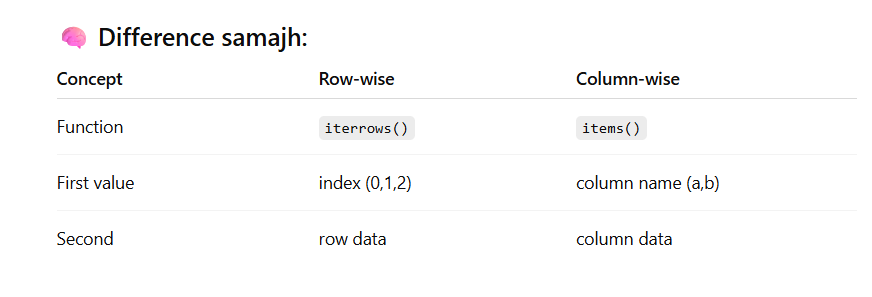

In [ ]:
df1

In [ ]:
def func_sum(x):
    return x.sum()

# Defines a function 'func_sum'
# Takes input x (a column or row of numbers)
# Returns the sum of all values in x

In [ ]:
df1

In [ ]:
df1.apply(func_sum, axis =0)
# Applies func_sum() on each column (axis=0 means column-wise)
# For every column, all values are summed
# Returns a result with sum of each column

In [ ]:
df1

In [ ]:
df1.apply(func_sum, axis =1)
# Applies func_sum() on each column (axis=0 means column-wise)
# For every column, all values are summed
# Returns a result with sum of each column

In [ ]:
df1.applymap(lambda x: x**2)
# Applies the function to every single element in the DataFrame
# Squares each value (x**2)
# Returns a new DataFrame with all values squared

In [ ]:
df1

In [ ]:
data = {"a": [100, 200, 13, 4],
       "b": [5, 5, 6, 7],
       "c": ["pw", "skills", "aj", "cj"]}
df2 = pd.DataFrame(data)

# Creates a dictionary with columns a, b, c and their values
# Converts this dictionary into a DataFrame named df2

In [ ]:
df2

In [ ]:
df2.sort_values(by = 'a')
# Sorts the DataFrame based on column 'a' in ascending order (default)
# Rows are rearranged according to values in column 'a'
# Returns a new sorted DataFrame (original df2 remains unchanged)

In [ ]:
df